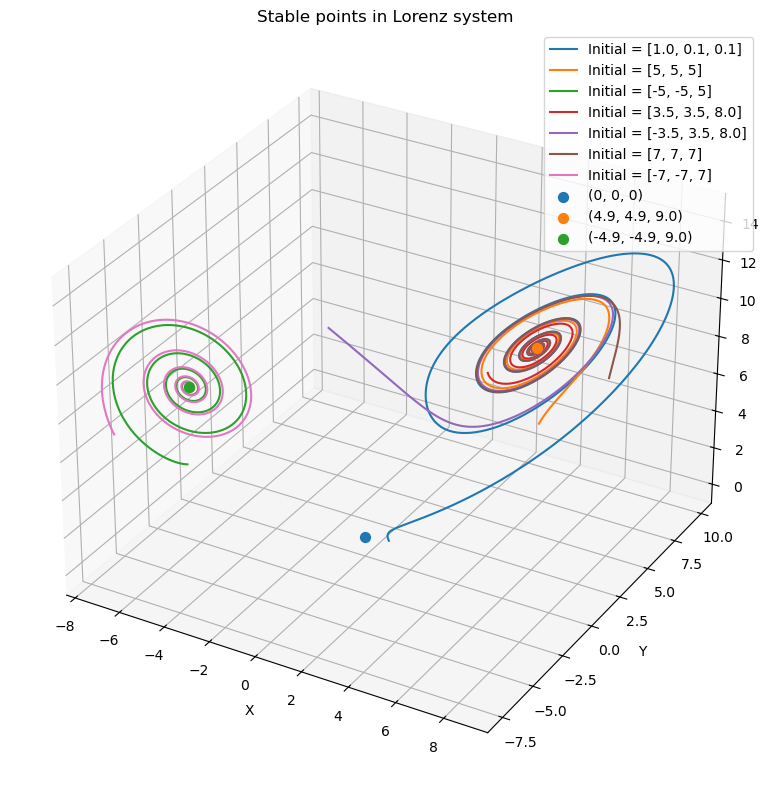

In [5]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

def lorenz_system(state, t, sigma, rho, beta):
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]

initial_states = [[1.0, 0.1, 0.1], [5, 5, 5], [-5, -5, 5], [3.5, 3.5, 8.0], [-3.5, 3.5, 8.0], 
                  [7, 7, 7], [-7, -7, 7]
]

time = np.linspace(0, 50, 10000)
sigma = 10
rho = 10
beta = 8 / 3

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for state in initial_states:
    sol = odeint(lorenz_system, state, time, args=(sigma, rho, beta))
    x, y, z = sol.T
    ax.plot(x, y, z, label=f'Initial = {state}')

equil = np.sqrt(beta * (rho - 1))
equilibria = [[0, 0, 0], [equil, equil, rho - 1], [-equil, -equil, rho - 1]]

for eq in equilibria:
    ax.scatter(*eq, s=50, label=f'{tuple(np.round(eq, 2))}')

ax.set_title('Stable points in Lorenz system')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.tight_layout()
plt.show()
